1. importing the necessary libraries

In [989]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

2. loading and reviewing the dataset

In [ ]:
df = pd.read_csv('/home/dev/Documents/Ml_Project/Heart Disease Prediction UCI/data/data.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [991]:
min_val = df['oldpeak'].min()
max_val = df['oldpeak'].max()

df['oldpeak'] = 1 + ((df['oldpeak'] - min_val) * (2 / (max_val - min_val)))
df['oldpeak'] = df['oldpeak'].astype(int)


3. Observation

In [992]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       1025 non-null   int64
 1   sex       1025 non-null   int64
 2   cp        1025 non-null   int64
 3   trestbps  1025 non-null   int64
 4   chol      1025 non-null   int64
 5   fbs       1025 non-null   int64
 6   restecg   1025 non-null   int64
 7   thalach   1025 non-null   int64
 8   exang     1025 non-null   int64
 9   oldpeak   1025 non-null   int64
 10  slope     1025 non-null   int64
 11  ca        1025 non-null   int64
 12  thal      1025 non-null   int64
 13  target    1025 non-null   int64
dtypes: int64(14)
memory usage: 112.2 KB


In [993]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.074146,0.273084,1.0,1.0,1.0,1.0,3.0


In [994]:
df.nunique() 

age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak       3
slope         3
ca            5
thal          4
target        2
dtype: int64

In [995]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [996]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [997]:
# thal mapping
thal_map = {0: None, 1: 6, 2: 3, 3: 7}
df['thal'] = df['thal'].map(thal_map)

# missing value (None/NaN) কে mode দিয়ে fill করা
mode_thal = df['thal'].mode()[0]
df['thal'] = df['thal'].fillna(mode_thal)
df['thal'] = df['thal'].astype(int)

In [998]:
for col in df.columns:
    vals = sorted(df[col].unique())
    if df[col].nunique() > 10 and df[col].dtype != 'object':
        print(f"{col}: {df[col].min()} - {df[col].max()}")
    else:
        print(f"{col}: {vals}")


age: 29 - 77
sex: [0, 1]
cp: [0, 1, 2, 3]
trestbps: 94 - 200
chol: 126 - 564
fbs: [0, 1]
restecg: [0, 1, 2]
thalach: 71 - 202
exang: [0, 1]
oldpeak: [1, 2, 3]
slope: [0, 1, 2]
ca: [0, 1, 2, 3, 4]
thal: [3, 6, 7]
target: [0, 1]


In [999]:
print(df['thal'].value_counts())
print(df[['thal']].head(20))

thal
3    551
7    410
6     64
Name: count, dtype: int64
    thal
0      7
1      7
2      7
3      7
4      3
5      3
6      6
7      7
8      7
9      3
10     3
11     7
12     3
13     7
14     3
15     3
16     3
17     7
18     3
19     3


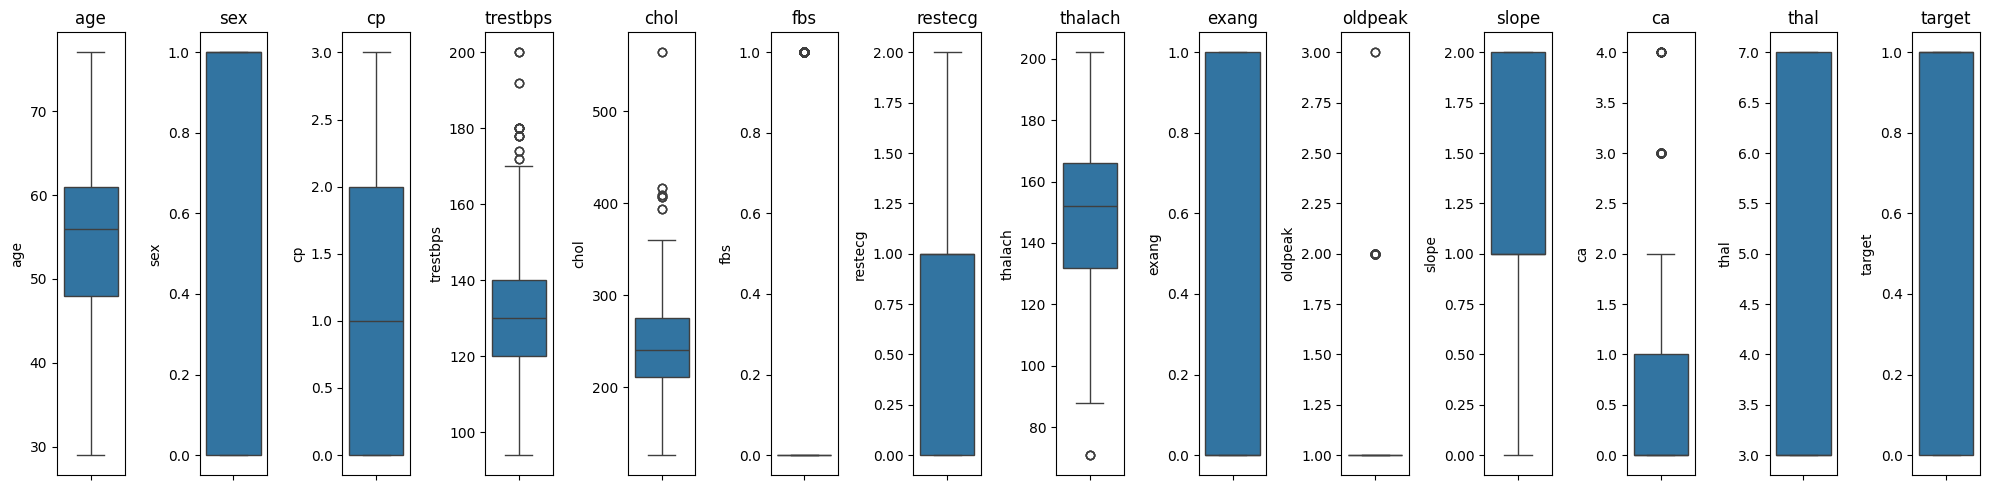

In [1000]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(20, 5))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, len(numeric_cols), i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

4.Plotting the distribution of target variable

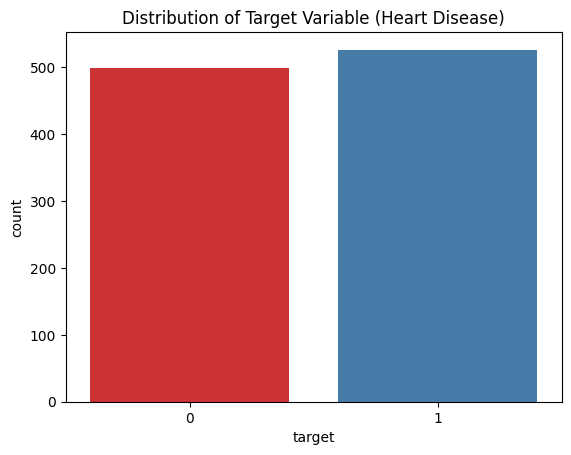

In [1001]:
sns.countplot(x='target', data=df, palette='Set1')
plt.title('Distribution of Target Variable (Heart Disease)')
plt.show()

5. Correlation Matrix

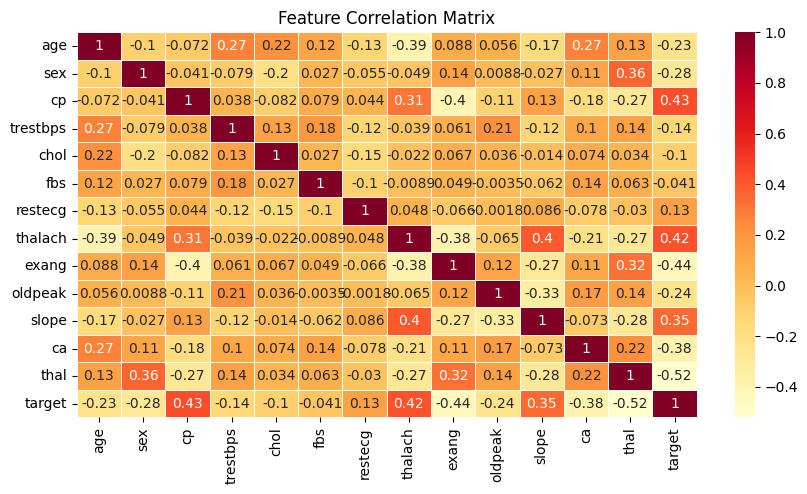

In [1002]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.corr(), annot=True, cmap='YlOrRd', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

6. Data Preprocessing

In [1003]:
x = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [1004]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [1005]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

X_test_prediction = model.predict(X_test)

accuracy = accuracy_score(y_test, X_test_prediction)

cm = confusion_matrix(y_test, X_test_prediction)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

precision = precision_score(y_test, X_test_prediction)

recall = recall_score(y_test, X_test_prediction)

f1 = f1_score(y_test, X_test_prediction)

metrics = {
    'Accuracy (%)': [accuracy * 100],
    'Precision (%)': [precision * 100],
    'Recall (%)': [recall * 100],
    'F1 Score (%)': [f1 * 100],
    'Specificity (%)': [specificity * 100],
}

results_table = pd.DataFrame(metrics)
print(results_table.round(2))

   Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)  Specificity (%)
0         84.88          81.65        89.0         85.17            80.95


In [1006]:
model2 = RandomForestClassifier(random_state=42)
model2.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [1007]:
Y_test_prediction = model2.predict(X_test)

accuracy = accuracy_score(y_test, Y_test_prediction)
precision = precision_score(y_test, Y_test_prediction)
recall = recall_score(y_test, Y_test_prediction)
f1 = f1_score(y_test, Y_test_prediction)

cm = confusion_matrix(y_test, Y_test_prediction)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

metrics = {
    'Accuracy (%)': [accuracy * 100],
    'Precision (%)': [precision * 100],
    'Recall (%)': [recall * 100],
    'F1 Score (%)': [f1 * 100],
    'Specificity (%)': [specificity * 100],
}

results_table = pd.DataFrame(metrics)
print(results_table.round(2))


   Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)  Specificity (%)
0         100.0          100.0       100.0         100.0            100.0


In [1008]:
model3 = KNeighborsClassifier(n_neighbors=5)
model3.fit(X_train, y_train)

KNeighborsClassifier()

In [1009]:
y_test_prediction = model3.predict(X_test)

accuracy = accuracy_score(y_test, y_test_prediction)
precision = precision_score(y_test, y_test_prediction)
recall = recall_score(y_test, y_test_prediction)
f1 = f1_score(y_test, y_test_prediction)

cm = confusion_matrix(y_test, y_test_prediction)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

metrics = {
    'Accuracy (%)': [accuracy * 100],
    'Precision (%)': [precision * 100],
    'Recall (%)': [recall * 100],
    'F1 Score (%)': [f1 * 100],
    'Specificity (%)': [specificity * 100],
}

results_table = pd.DataFrame(metrics)
print(results_table.round(2))


   Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)  Specificity (%)
0         71.71          68.75        77.0         72.64            66.67


In [1010]:
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

GaussianNB()

In [1011]:
y_pred = model_nb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)


metrics = {
    'Accuracy (%)': [accuracy * 100],
    'Precision (%)': [precision * 100],
    'Recall (%)': [recall * 100],
    'F1 Score (%)': [f1 * 100],
    'Specificity (%)': [specificity * 100],
}

results_table = pd.DataFrame(metrics)
print(results_table.round(2))


   Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)  Specificity (%)
0         84.39          78.81        93.0         85.32            76.19
